In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [3]:
np.random.seed(3465)
n_neur=30
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(30, 30)

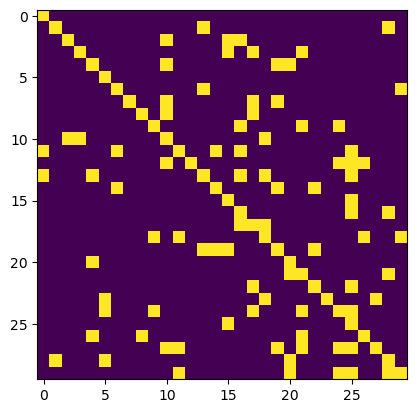

In [4]:
plt.imshow(A!=0)

In [5]:
def continuous_noise_fun(num, l=5000):
    xx = np.linspace(0,500,l)
    noise = np.zeros((num,l))
    for i in range(num):
        a = 2*np.random.normal(0,0.25,size=6)
        c = 500*(np.random.random(size=6))
        s = 1+100*(np.random.random(size=6))
        yy = 0*xx
        for j in range(6):
            yy = yy + a[j]*np.exp(-(xx-c[j])**2/s[j]) 
        noise[i] = yy
    return noise 
np.random.seed(13)

noise = continuous_noise_fun(num=n_neur, l=5000)

In [6]:
noise.shape

(30, 5000)

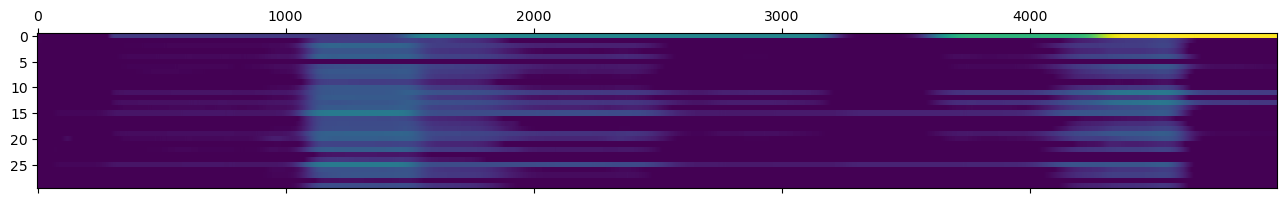

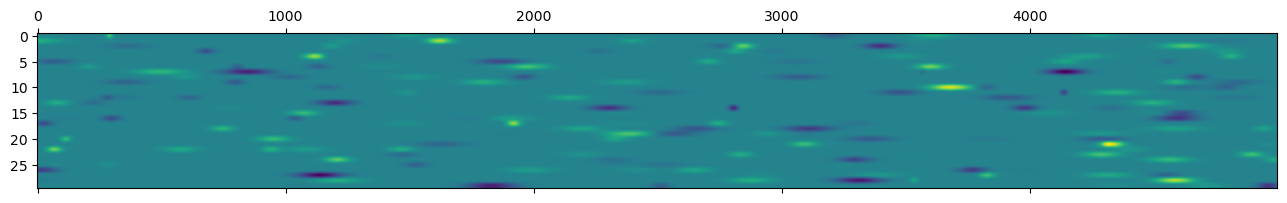

In [7]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A @ X[i] + 0.05*np.random.normal(0,0.25,A.shape[0]) + noise[:,i]
X=X.T
plt.matshow(X, aspect='auto',vmin=0)
plt.matshow(noise, aspect='auto', interpolation=None)

In [8]:
np.zeros((7,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## Analysis

In [9]:
N_PASTS, n_lags, n_perm = np.arange(1, 8, 1), 1, 1000
alpha, beta = 0.01, 0.001

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete


0 pasts


INFO:src.d_CSL:Step 1/1800 (0.06% complete)
INFO:src.d_CSL:Step 1/1800 (0.06% complete)
INFO:src.d_CSL:Step 2/1800 (0.11% complete)
INFO:src.d_CSL:Step 2/1800 (0.11% complete)
INFO:src.d_CSL:Step 3/1800 (0.17% complete)
INFO:src.d_CSL:Step 3/1800 (0.17% complete)
INFO:src.d_CSL:Step 4/1800 (0.22% complete)
INFO:src.d_CSL:Step 4/1800 (0.22% complete)
INFO:src.d_CSL:Step 5/1800 (0.28% complete)
INFO:src.d_CSL:Step 5/1800 (0.28% complete)
INFO:src.d_CSL:Step 6/1800 (0.33% complete)
INFO:src.d_CSL:Step 6/1800 (0.33% complete)
INFO:src.d_CSL:Step 7/1800 (0.39% complete)
INFO:src.d_CSL:Step 7/1800 (0.39% complete)
INFO:src.d_CSL:Step 8/1800 (0.44% complete)
INFO:src.d_CSL:Step 8/1800 (0.44% complete)
INFO:src.d_CSL:Step 9/1800 (0.50% complete)
INFO:src.d_CSL:Step 9/1800 (0.50% complete)
INFO:src.d_CSL:Step 10/1800 (0.56% complete)
INFO:src.d_CSL:Step 10/1800 (0.56% complete)
INFO:src.d_CSL:Step 11/1800 (0.61% complete)
INFO:src.d_CSL:Step 11/1800 (0.61% complete)
INFO:src.d_CSL:Step 12/1800 

INFO:src.d_CSL:Step 94/1800 (5.22% complete)
INFO:src.d_CSL:Step 91/1800 (5.06% complete)
INFO:src.d_CSL:Step 95/1800 (5.28% complete)
INFO:src.d_CSL:Step 92/1800 (5.11% complete)
INFO:src.d_CSL:Step 96/1800 (5.33% complete)
INFO:src.d_CSL:Step 93/1800 (5.17% complete)
INFO:src.d_CSL:Step 97/1800 (5.39% complete)
INFO:src.d_CSL:Step 94/1800 (5.22% complete)
INFO:src.d_CSL:Step 98/1800 (5.44% complete)
INFO:src.d_CSL:Step 95/1800 (5.28% complete)
INFO:src.d_CSL:Step 99/1800 (5.50% complete)
INFO:src.d_CSL:Step 96/1800 (5.33% complete)
INFO:src.d_CSL:Step 100/1800 (5.56% complete)
INFO:src.d_CSL:Step 97/1800 (5.39% complete)
INFO:src.d_CSL:Step 101/1800 (5.61% complete)
INFO:src.d_CSL:Step 98/1800 (5.44% complete)
INFO:src.d_CSL:Step 102/1800 (5.67% complete)
INFO:src.d_CSL:Step 99/1800 (5.50% complete)
INFO:src.d_CSL:Step 103/1800 (5.72% complete)
INFO:src.d_CSL:Step 100/1800 (5.56% complete)
INFO:src.d_CSL:Step 104/1800 (5.78% complete)
INFO:src.d_CSL:Step 101/1800 (5.61% complete)
INF

INFO:src.d_CSL:Step 179/1800 (9.94% complete)
INFO:src.d_CSL:Step 185/1800 (10.28% complete)
INFO:src.d_CSL:Step 180/1800 (10.00% complete)
INFO:src.d_CSL:Step 186/1800 (10.33% complete)
INFO:src.d_CSL:Step 181/1800 (10.06% complete)
INFO:src.d_CSL:Step 187/1800 (10.39% complete)
INFO:src.d_CSL:Step 182/1800 (10.11% complete)
INFO:src.d_CSL:Step 188/1800 (10.44% complete)
INFO:src.d_CSL:Step 183/1800 (10.17% complete)
INFO:src.d_CSL:Step 189/1800 (10.50% complete)
INFO:src.d_CSL:Step 184/1800 (10.22% complete)
INFO:src.d_CSL:Step 190/1800 (10.56% complete)
INFO:src.d_CSL:Step 185/1800 (10.28% complete)
INFO:src.d_CSL:Step 191/1800 (10.61% complete)
INFO:src.d_CSL:Step 186/1800 (10.33% complete)
INFO:src.d_CSL:Step 192/1800 (10.67% complete)
INFO:src.d_CSL:Step 187/1800 (10.39% complete)
INFO:src.d_CSL:Step 193/1800 (10.72% complete)
INFO:src.d_CSL:Step 188/1800 (10.44% complete)
INFO:src.d_CSL:Step 194/1800 (10.78% complete)
INFO:src.d_CSL:Step 189/1800 (10.50% complete)
INFO:src.d_CSL

...

INFO:src.d_CSL:Step 6647/7200 (92.32% complete)
INFO:src.d_CSL:Step 7115/7200 (98.82% complete)
INFO:src.d_CSL:Step 6648/7200 (92.33% complete)
INFO:src.d_CSL:Step 7116/7200 (98.83% complete)
INFO:src.d_CSL:Step 6649/7200 (92.35% complete)
INFO:src.d_CSL:Step 7117/7200 (98.85% complete)
INFO:src.d_CSL:Step 6650/7200 (92.36% complete)
INFO:src.d_CSL:Step 7118/7200 (98.86% complete)
INFO:src.d_CSL:Step 6651/7200 (92.38% complete)
INFO:src.d_CSL:Step 7119/7200 (98.88% complete)
INFO:src.d_CSL:Step 6652/7200 (92.39% complete)
INFO:src.d_CSL:Step 7120/7200 (98.89% complete)
INFO:src.d_CSL:Step 7121/7200 (98.90% complete)
INFO:src.d_CSL:Step 6653/7200 (92.40% complete)
INFO:src.d_CSL:Step 7122/7200 (98.92% complete)
INFO:src.d_CSL:Step 6654/7200 (92.42% complete)
INFO:src.d_CSL:Step 7123/7200 (98.93% complete)
INFO:src.d_CSL:Step 6655/7200 (92.43% complete)
INFO:src.d_CSL:Step 7124/7200 (98.94% complete)
INFO:src.d_CSL:Step 6656/7200 (92.44% complete)
INFO:src.d_CSL:Step 7125/7200 (98.96% co

INFO:src.d_CSL:Step 6732/7200 (93.50% complete)
INFO:src.d_CSL:Step 6733/7200 (93.51% complete)
INFO:src.d_CSL:Step 6734/7200 (93.53% complete)
INFO:src.d_CSL:Step 6735/7200 (93.54% complete)
INFO:src.d_CSL:Step 6736/7200 (93.56% complete)
INFO:src.d_CSL:Step 6737/7200 (93.57% complete)
INFO:src.d_CSL:Step 6738/7200 (93.58% complete)
INFO:src.d_CSL:Step 6739/7200 (93.60% complete)
INFO:src.d_CSL:Step 6740/7200 (93.61% complete)
INFO:src.d_CSL:Step 6741/7200 (93.62% complete)
INFO:src.d_CSL:Step 6742/7200 (93.64% complete)
INFO:src.d_CSL:Step 6743/7200 (93.65% complete)
INFO:src.d_CSL:Step 6744/7200 (93.67% complete)
INFO:src.d_CSL:Step 6745/7200 (93.68% complete)
INFO:src.d_CSL:Step 6746/7200 (93.69% complete)
INFO:src.d_CSL:Step 6747/7200 (93.71% complete)
INFO:src.d_CSL:Step 6748/7200 (93.72% complete)
INFO:src.d_CSL:Step 6749/7200 (93.74% complete)
INFO:src.d_CSL:Step 6750/7200 (93.75% complete)
INFO:src.d_CSL:Step 6751/7200 (93.76% complete)
INFO:src.d_CSL:Step 6752/7200 (93.78% co

INFO:src.d_CSL:Step 6903/7200 (95.88% complete)
INFO:src.d_CSL:Step 6904/7200 (95.89% complete)
INFO:src.d_CSL:Step 6905/7200 (95.90% complete)
INFO:src.d_CSL:Step 6906/7200 (95.92% complete)
INFO:src.d_CSL:Step 6907/7200 (95.93% complete)
INFO:src.d_CSL:Step 6908/7200 (95.94% complete)
INFO:src.d_CSL:Step 6909/7200 (95.96% complete)
INFO:src.d_CSL:Step 6910/7200 (95.97% complete)
INFO:src.d_CSL:Step 6911/7200 (95.99% complete)
INFO:src.d_CSL:Step 6912/7200 (96.00% complete)
INFO:src.d_CSL:Step 6913/7200 (96.01% complete)
INFO:src.d_CSL:Step 6914/7200 (96.03% complete)
INFO:src.d_CSL:Step 6915/7200 (96.04% complete)
INFO:src.d_CSL:Step 6916/7200 (96.06% complete)
INFO:src.d_CSL:Step 6917/7200 (96.07% complete)
INFO:src.d_CSL:Step 6918/7200 (96.08% complete)
INFO:src.d_CSL:Step 6919/7200 (96.10% complete)
INFO:src.d_CSL:Step 6920/7200 (96.11% complete)
INFO:src.d_CSL:Step 6921/7200 (96.12% complete)
INFO:src.d_CSL:Step 6922/7200 (96.14% complete)
INFO:src.d_CSL:Step 6923/7200 (96.15% co

INFO:src.d_CSL:Step 7074/7200 (98.25% complete)
INFO:src.d_CSL:Step 7075/7200 (98.26% complete)
INFO:src.d_CSL:Step 7076/7200 (98.28% complete)
INFO:src.d_CSL:Step 7077/7200 (98.29% complete)
INFO:src.d_CSL:Step 7078/7200 (98.31% complete)
INFO:src.d_CSL:Step 7079/7200 (98.32% complete)
INFO:src.d_CSL:Step 7080/7200 (98.33% complete)
INFO:src.d_CSL:Step 7081/7200 (98.35% complete)
INFO:src.d_CSL:Step 7082/7200 (98.36% complete)
INFO:src.d_CSL:Step 7083/7200 (98.38% complete)
INFO:src.d_CSL:Step 7084/7200 (98.39% complete)
INFO:src.d_CSL:Step 7085/7200 (98.40% complete)
INFO:src.d_CSL:Step 7086/7200 (98.42% complete)
INFO:src.d_CSL:Step 7087/7200 (98.43% complete)
INFO:src.d_CSL:Step 7088/7200 (98.44% complete)
INFO:src.d_CSL:Step 7089/7200 (98.46% complete)
INFO:src.d_CSL:Step 7090/7200 (98.47% complete)
INFO:src.d_CSL:Step 7091/7200 (98.49% complete)
INFO:src.d_CSL:Step 7092/7200 (98.50% complete)
INFO:src.d_CSL:Step 7093/7200 (98.51% complete)
INFO:src.d_CSL:Step 7094/7200 (98.53% co

CPU times: total: 1d 6h 27min 17s
Wall time: 5h 2min


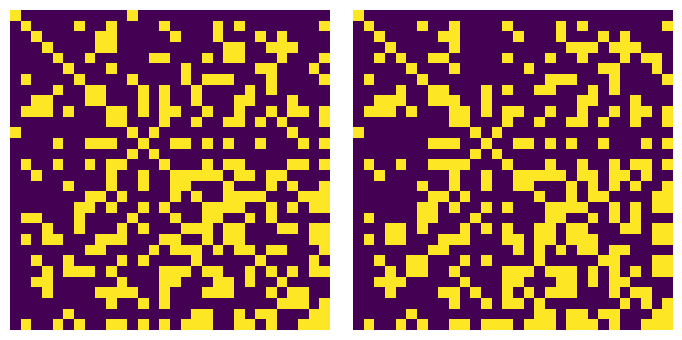

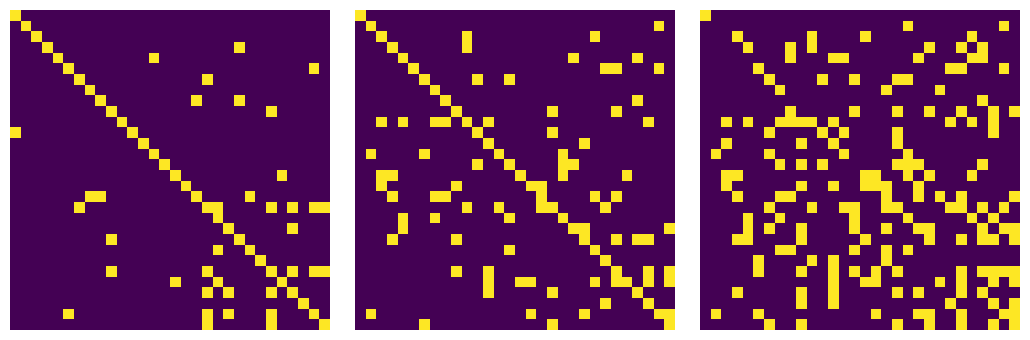

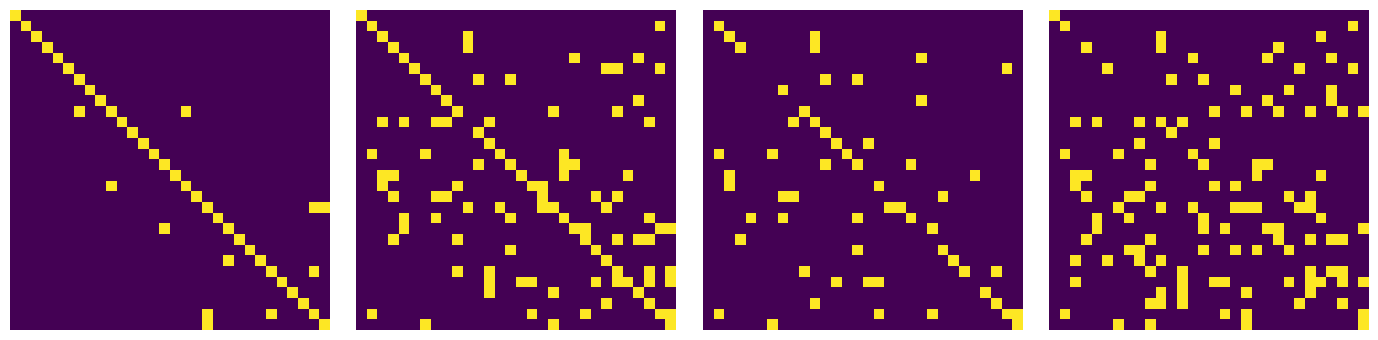

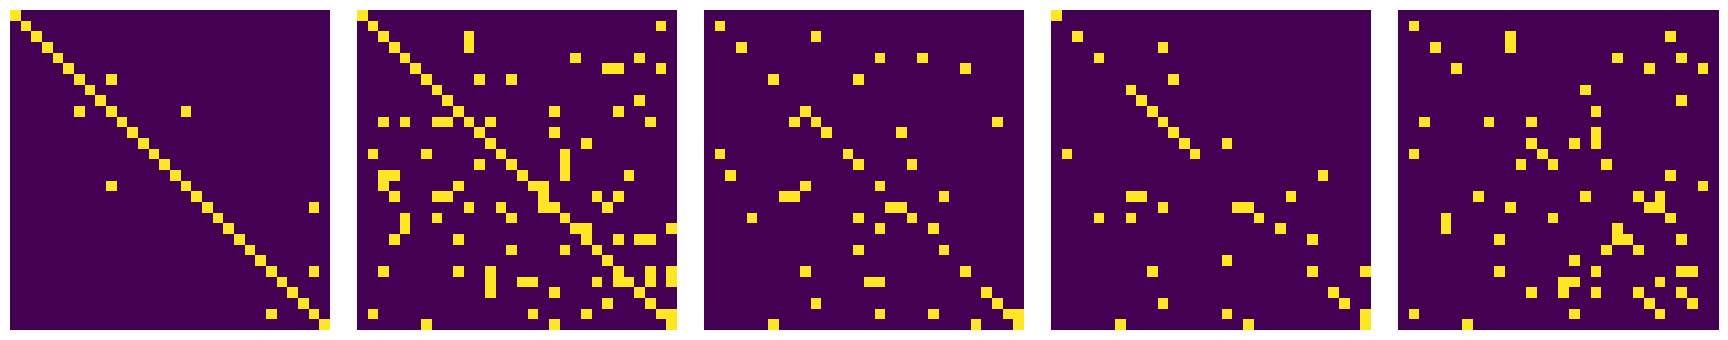

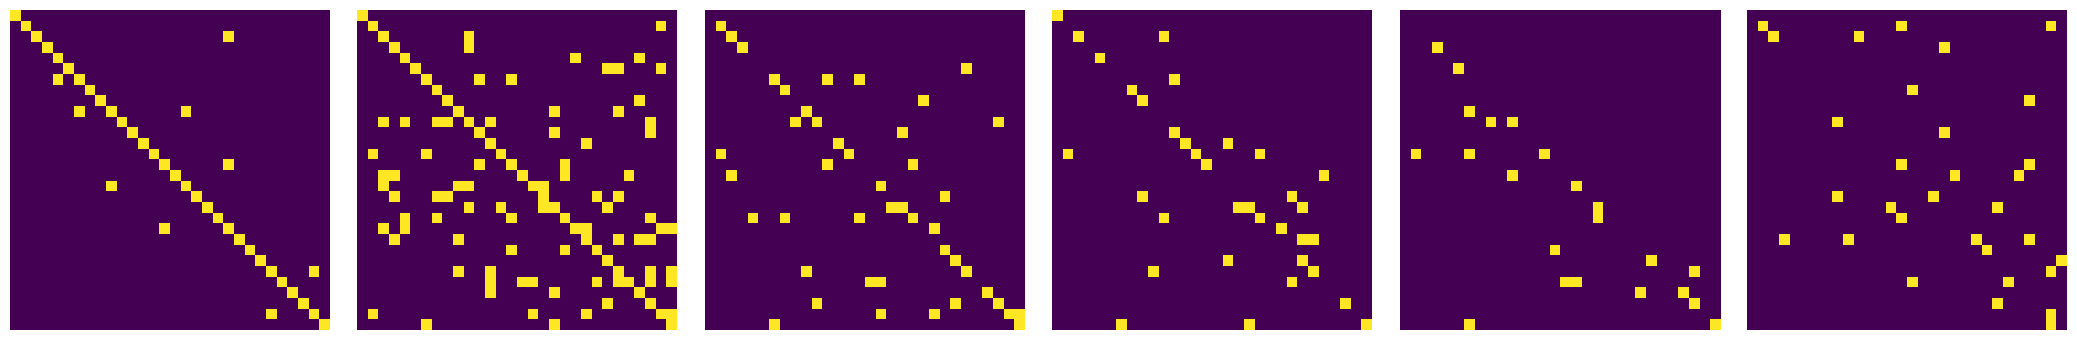

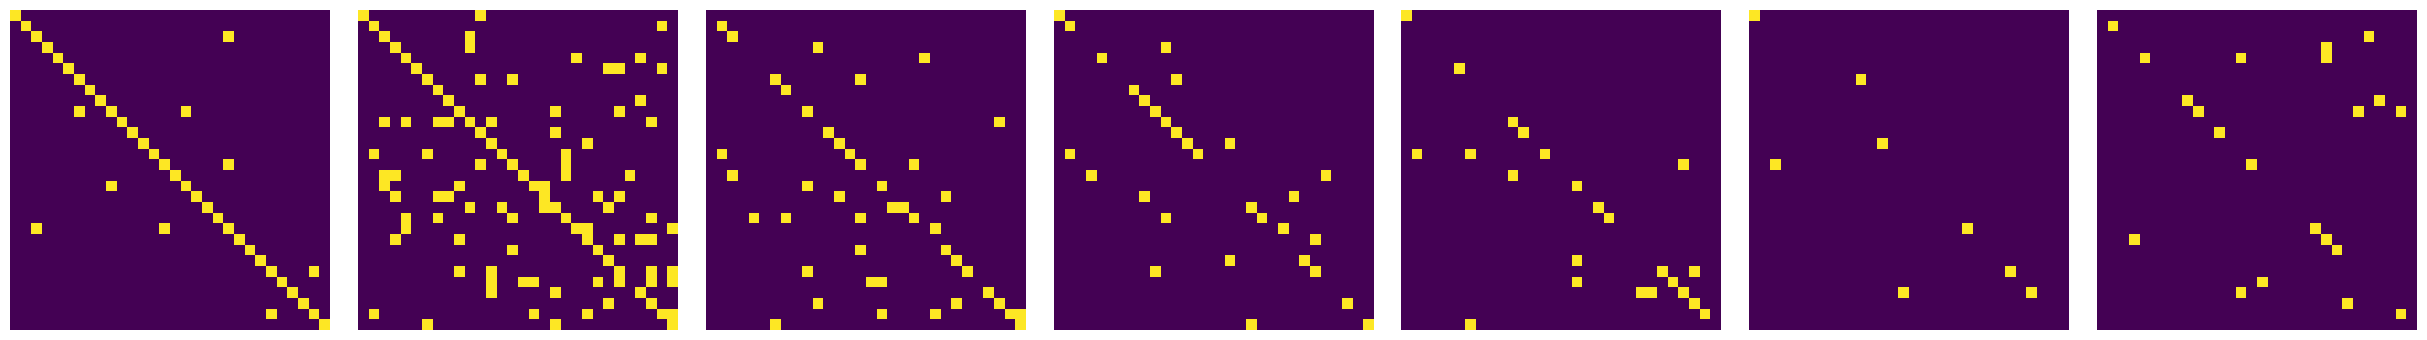

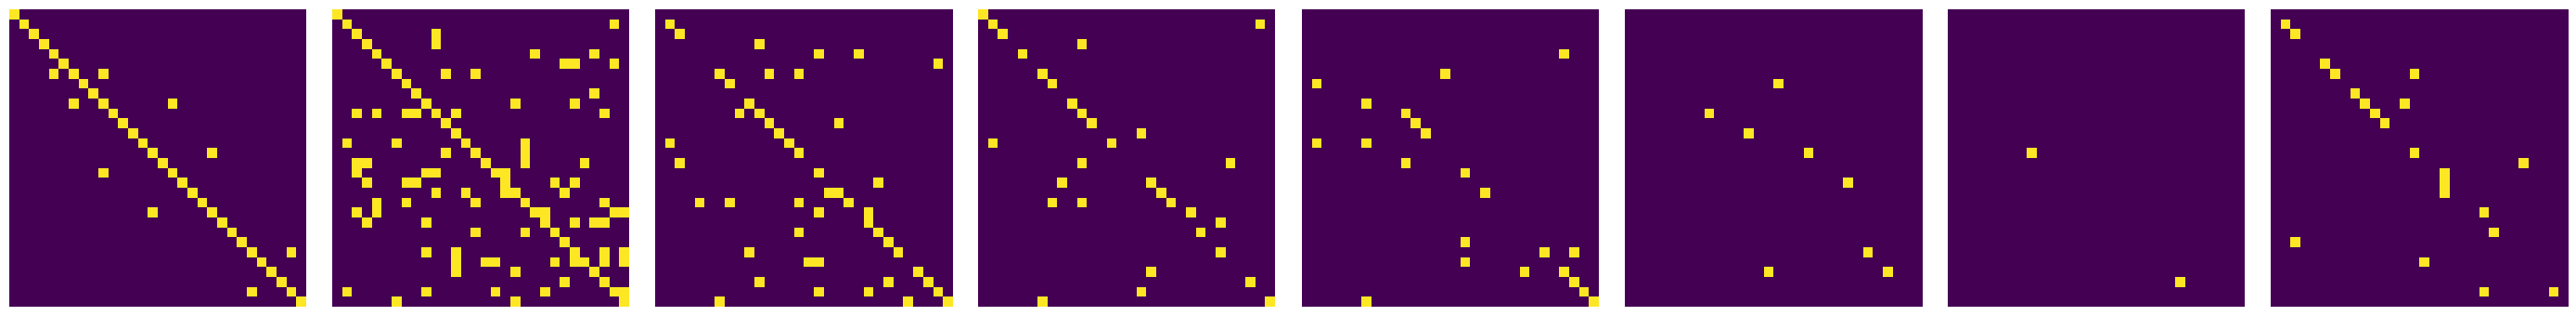

In [10]:
%%time
metrics = np.zeros((7,4))
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
    gcstar.fit(X, verbose = 0)
    
    inf = gcstar.get_connectivity_matrix()
    gcstar.plot_extended_connectivity_matrix(alpha = 0.01, 
                                                 beta = 0.001)
    gcstar.compute_confusion_matrix(A, simulation = True)
    metrics[i] =  gcstar.compute_metrics()

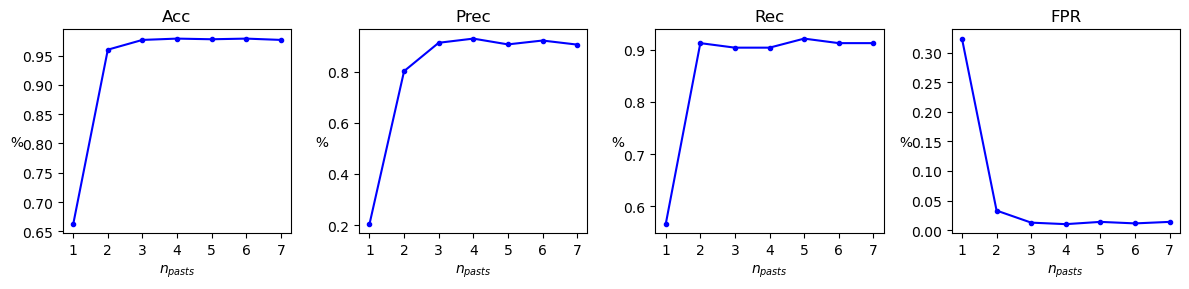

In [14]:
labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(1, 8, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()